<div style="font-family:'Times New Roman';">

conda create -n proteomics python=3.9

pip install pyteomics

conda activate proteomics

pip install pyteomics

conda install -c bioconda pyteomics

conda install conda-forge::numpy

conda install conda-forge::matplotlib

conda install conda-forge::lxml

conda install anaconda::pandas

conda install conda-forge::sqlalchemy

conda install conda-forge::pynumpress

conda install conda-forge::h5py

pip install psims

conda install bioconda::spectrum_utils

<div style="font-family:'Times New Roman';">

**Propiedades de los péptidos: masa, carga, retención cromatográfica** 

**1. Composición, masa e isótopos**

**2. Carga y pI**

**3. Predicción del tiempo de retención**

<div style="font-family:'Times New Roman';">

**Composición, masa e isótopos**

Las funciones relacionadas con los cálculos de masa y distribuciones isotópicas están organizadas en el pyteomics.massmódulo.

Hay una pyteomics.mass.Compositionclase destinada a almacenar fórmulas químicas. pyteomics.mass.CompositionLos objetos son diccionarios que se pueden sumar o restar entre sí o multiplicar por números enteros.

In [8]:
from pyteomics import mass
p = mass.Composition(formula='HO3P')
#Composition({'H': 1, 'O': 3, 'P': 1})

In [4]:
mass.std_aa_comp['T']

Composition({'H': 7, 'C': 4, 'O': 2, 'N': 1})

In [5]:
p + mass.std_aa_comp['T']

Composition({'H': 8, 'O': 5, 'P': 1, 'C': 4, 'N': 1})

<div style="font-family:'Times New Roman';">

Los valores de pyteomics.mass.std_aa_compson pyteomics.mass.Compositionobjetos. Puedes realizar operaciones aritméticas básicas con Compositionobjetos: sumar, restar y multiplicar por enteros.

Todas las funciones que aceptan un argumento de palabra clave de fórmula suman y restan números que siguen al mismo átomo en la fórmula:

In [9]:
from pyteomics import mass
mass.calculate_mass(formula='C2H6') # Ethane

30.04695019242

In [10]:
mass.calculate_mass(formula='C2H6H-2') # Ethylene

28.03130012828

<div style="font-family:'Times New Roman';">

**Cálculos básicos de masa**
 
La tarea más común en el análisis de datos de espectrometría de masas es calcular la masa de una molécula orgánica o un péptido, o la relación m/z de un ion. Este tipo de tareas se pueden realizar con la pyteomics.mass.calculate_mass()función. Trabaja con fórmulas químicas, secuencias polipeptídicas en notación modX, secuencias preanalizadas y diccionarios de composiciones químicas. Internamente, todos los tipos de entrada se convierten en una :py:class`Composition` para el cálculo de la masa.

In [11]:
from pyteomics import mass
mass.calculate_mass(formula='H2O')

18.0105646837

In [13]:
mass.calculate_mass(formula='C2H5OH')


46.04186481198

In [14]:
mass.calculate_mass(composition={'H':2, 'O':1})

18.0105646837

In [15]:
mass.calculate_mass(sequence='PEPTIDE')
799.359964027207

799.359964027207

In [16]:
from pyteomics import parser
ps = parser.parse('PEPTIDE', show_unmodified_termini=True)
mass.calculate_mass(parsed_sequence=ps)


799.35996402671

<div style="font-family:'Times New Roman';">

**Relación masa-carga de iones** 

pyteomics.mass.calculate_mass()Se puede utilizar para calcular la relación masa/carga de iones peptídicos y fragmentos ionizados. Para ello, simplemente indique el tipo de fragmento peptídico ionizado y su carga:

In [17]:
from pyteomics import mass
mass.calculate_mass(sequence='PEPTIDE', ion_type='M', charge=2)


400.687258480125

In [18]:
mass.calculate_mass(sequence='PEP', ion_type='b', charge=1)

324.15539725243997

In [19]:
mass.calculate_mass(sequence='TIDE', ion_type='y', charge=1)

477.21911970781

<div style="font-family:'Times New Roman';">

**Masa de péptidos modificados**

También pyteomics.mass.calculate_mass() calcula las masas de péptidos modificados. Para que la función reconozca el residuo modificado, es necesario agregar la información sobre su composición elemental al pyteomics.mass.std_aa_compdiccionario utilizado en los cálculos por defecto.

In [21]:
from pyteomics import mass
mass.std_aa_comp['pT'] = mass.Composition({'C': 4, 'H': 8, 'N': 1, 'O': 5, 'P': 1})
mass.calculate_mass(sequence='PEPpTIDE')

879.3262945474601

<div style="font-family:'Times New Roman';">

Para agregar información sobre aminoácidos modificados a un aa_compdiccionario definido por el usuario, se puede agregar la información de composición para un residuo modificado específico o solo para una modificación:

In [22]:
from pyteomics import mass
aa_comp = dict(mass.std_aa_comp)
aa_comp['p'] = mass.Composition('HPO3')
mass.calculate_mass('pT', aa_comp=aa_comp)

199.02457367286001

<div style="font-family:'Times New Roman';">

En este ejemplo, invocamos calculate_mass() con un argumento posicional (no una palabra clave) ('pT'). Esta función se añadió en la versión 1.2.4. Al proporcionar un argumento no clave, se tratará como una secuencia; si falla, se tratará como una fórmula; en caso de que también falle, PyteomicsErrorse lanzará una función. Tenga en cuenta que 'pT' se trata como una secuencia, por lo que se implican los grupos terminales predeterminados al calcular la composición y la masa:

In [23]:
mass.calculate_mass('pT', aa_comp=aa_comp) == mass.calculate_mass(aa_comp['p']) + mass.calculate_mass(aa_comp['T']) + mass.calculate_mass('H2O')

True

<div style="font-family:'Times New Roman';">

Puede crear una entrada específica para un aminoácido modificado para anular la modificación en un residuo específico:

In [24]:
aa_comp['pT'] = mass.Composition({'N': 2})
mass.Composition('pT', aa_comp=aa_comp)

Composition({'H': 2, 'N': 2, 'O': 1})

In [25]:
mass.Composition('pS', aa_comp=aa_comp)

Composition({'H': 8, 'P': 1, 'O': 6, 'C': 3, 'N': 1})

<div style="font-family:'Times New Roman';">

La base de datos Unimod es un excelente recurso para obtener información sobre las composiciones químicas de las modificaciones proteicas conocidas. pyteomics.mass.UnimodLa clase es una interfaz Python simple para Unimod:

In [26]:
db = mass.Unimod()
aa_comp = dict(mass.std_aa_comp)
aa_comp['p'] = db.by_title('Phospho')['composition']
mass.calculate_mass('PEpTIDE', aa_comp=aa_comp)

782.27353069861

<div style="font-family:'Times New Roman';">

**Cálculos de masa más rápidos**
 
Si bien pyteomics.mass.calculate_mass()su interfaz es flexible y práctica, puede resultar demasiado lenta para cálculos a gran escala. Existe una versión optimizada y simplificada de esta función llamada pyteomics.mass.fast_mass(). Funciona únicamente con secuencias sin modificar en la notación IUPAC estándar de una letra. Al igual que pyteomics.mass.calculate_mass(), pyteomics.mass.fast_mass()puede calcular m/z al proporcionar el tipo y la carga del ion. Las masas de los aminoácidos se pueden especificar mediante el aa_massargumento .

In [28]:
from pyteomics import mass
mass.fast_mass('PEPTIDE')

799.3599640267099

<div style="font-family:'Times New Roman';">

Si necesita calcular la masa o m/z de un péptido con modificaciones o grupos terminales no estándar, pero no desea especificar todas las composiciones, también puede usar la pyteomics.mass.fast_mass2()función. Funciona aa_massde la misma manera que fast_mass(), pero es totalmente compatible con modX :

In [29]:
mass.fast_mass2('H-PEPTIDE-OH')

799.3599640267099

<div style="font-family:'Times New Roman';">

Si no se especifica, pyteomics.massse asume que las sustancias se encuentran en estado isotópico puro. Sin embargo, se puede especificar un estado isotópico específico entre paréntesis (p. ej., O[18], N[15]) en una fórmula química. Se asume que un elemento con estado isotópico no especificado tiene la masa del isótopo más estable y una abundancia del 100 %.



In [30]:
mass.calculate_mass(formula='H[2]2O') # Heavy water

20.02311817516

In [31]:
mass.calculate_mass(formula='H[2]HO') # Semiheavy water

19.01684142943

<div style="font-family:'Times New Roman';">

pyteomics.mass.isotopic_composition_abundance()La función calcula la abundancia relativa de un estado isotópico dado de una molécula. La entrada puede proporcionarse como una fórmula o como una composición/dictado.

In [32]:
from pyteomics import mass
mass.isotopic_composition_abundance(formula='H2O') # Water with an unspecified isotopic state

1.0

In [33]:
mass.isotopic_composition_abundance(formula='H[2]2O') # Heavy water

1.3225000000000001e-08

In [36]:
mass.isotopic_composition_abundance(formula='H[2]H[1]O') # Semiheavy water

0.00022997355

In [38]:
mass.isotopic_composition_abundance(formula='H[2]2O[18]') # Heavy-hydrogen heavy-oxygen water


2.7111250000000005e-11

<div style="font-family:'Times New Roman';">

Finalmente, se puede determinar la composición isotópica más probable de una sustancia con pyteomics.mass.most_probable_isotopic_composition()función. La sustancia se especifica como una fórmula, un pyteomics.mass.Composition objeto o una cadena de secuencia modX.



In [39]:
from pyteomics import mass
mass.most_probable_isotopic_composition(formula='H2SO4')

(Composition({'H[1]': 2, 'S[32]': 1, 'O[16]': 4}), 0.9404842232093018)

In [40]:
mass.most_probable_isotopic_composition(formula='C300H602')

(Composition({'C[12]': 297, 'C[13]': 3, 'H[1]': 602}), 0.2086217335468455)

In [41]:
mass.most_probable_isotopic_composition(sequence='PEPTIDE'*100)


(Composition({'H[1]': 5101, 'H[2]': 1, 'C[12]': 3364, 'C[13]': 36, 'O[16]': 1398, 'O[18]': 3, 'N[14]': 697, 'N[15]': 3}),
 0.0006164866605174921)

<div style="font-family:'Times New Roman';">

información sobre los elementos químicos, sus isótopos y abundancias relativas se almacena en el pyteomics.mass.nist_massdiccionario.

In [43]:
from pyteomics import mass
print (mass.nist_mass['C'])

{0: (12.0, 1.0), 8: (8.037675, 0.0), 9: (9.0310367, 0.0), 10: (10.0168532, 0.0), 11: (11.0114336, 0.0), 12: (12.0, 0.9893), 13: (13.0033548378, 0.0107), 14: (14.003241989, 0.0), 15: (15.0105993, 0.0), 16: (16.014701, 0.0), 17: (17.022586, 0.0), 18: (18.02676, 0.0), 19: (19.03481, 0.0), 20: (20.04032, 0.0), 21: (21.04934, 0.0), 22: (22.0572, 0.0)}


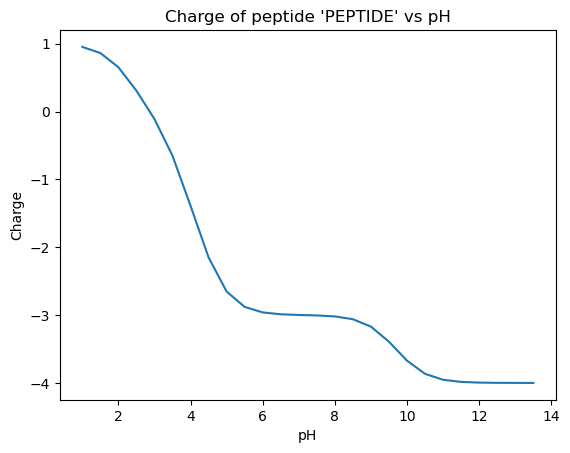

In [1]:
import pylab
import numpy as np
from pyteomics import electrochem

pHs = np.arange(1, 14, 0.5) # list of values of pH
charges = electrochem.charge('PEPTIDE', pHs) # charge function accepts lists of pHs

pylab.figure()
pylab.plot(pHs, charges)
pylab.title("Charge of peptide 'PEPTIDE' vs pH")
pylab.xlabel('pH')
pylab.ylabel('Charge')
pylab.show()